# HW14 - эмбеддинги, FAISS, оценка retrieval и mini-RAG

## 1. Импорты, seed и среда

In [5]:
import sys
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

import faiss

warnings.filterwarnings("ignore")

try:
    import torch
    import torch.nn.functional as F
    HAS_TORCH = True
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
except ImportError:
    torch = None
    F = None
    HAS_TORCH = False
    device = "cpu"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

if HAS_TORCH:
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

PROJECT_DIR = Path(".")
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
DATA_DIR = PROJECT_DIR / "data"
BASE_DATA_DIR = DATA_DIR / "base"
UPDATES_DATA_DIR = DATA_DIR / "updates"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Python environment")
print(f"Python:   {sys.version.split()[0]}")
print(f"sklearn:  {sklearn.__version__}")
print(f"numpy:    {np.__version__}")
print(f"pandas:   {pd.__version__}")
print(f"device:   {device}")
print(f"SEED:     {SEED}")

Python environment
Python:   3.11.4
sklearn:  1.5.2
numpy:    1.26.4
pandas:   2.2.3
device:   cpu
SEED:     42


## 2. База знаний и первичный анализ

In [7]:
def load_markdown_documents(folder: Path):
    if not folder.exists():
        raise FileNotFoundError(
            f"Не найдена папка с базой знаний: {folder}. "
            "Убедитесь, что структура homeworks/HW14/data/ создана корректно."
        )

    records = []
    for path in sorted(folder.glob("*.md")):
        raw_text = path.read_text(encoding="utf-8").strip()
        lines = [line.rstrip() for line in raw_text.splitlines()]
        non_empty = [line for line in lines if line.strip()]
        if not non_empty:
            continue

        first_line = non_empty[0]
        if first_line.startswith("#"):
            title = first_line.lstrip("#").strip()
            body_lines = lines[1:]
        else:
            title = path.stem.replace("_", " ").strip().title()
            body_lines = lines

        text = "\n".join(body_lines).strip()
        records.append({
            "source": path.stem,
            "title": title,
            "text": text,
            "filepath": str(path.as_posix())
        })

    return records

base_documents = load_markdown_documents(BASE_DATA_DIR)
update_documents = load_markdown_documents(UPDATES_DATA_DIR)

kb_df = pd.DataFrame(base_documents)
print(f"Число исходных документов (до обновления): {len(kb_df)}")
display(kb_df[["source", "title", "filepath"]].head())

print("\nПримеры документов / фрагментов:")
for _, row in kb_df.head(3).iterrows():
    print(f"\n[{row['source']}] {row['title']}")
    print(f"Файл: {row['filepath']}")
    print(row["text"][:350] + "...")

print(f"\nНовых документов для обновления базы: {len(update_documents)}")
display(pd.DataFrame(update_documents)[["source", "title", "filepath"]])


Число исходных документов (до обновления): 12


,source,title,filepath
0,admission_rules,Правила поступления и старт обучения,homeworks/HW14/data/base/admission_rules.md
1,certificates,Сертификаты и условия выдачи,homeworks/HW14/data/base/certificates.md
2,community_rules,Правила общения в сообществе,homeworks/HW14/data/base/community_rules.md
3,deadlines_resubmissions,Дедлайны и повторные отправки,homeworks/HW14/data/base/deadlines_resubmissio...
4,exam_rules,Правила итогового экзамена,homeworks/HW14/data/base/exam_rules.md



Примеры документов / фрагментов:

[admission_rules] Правила поступления и старт обучения
Файл: homeworks/HW14/data/base/admission_rules.md
Онлайн-школа DataBridge Academy принимает студентов на потоки с фиксированными датами старта. Чтобы попасть на курс, студент заполняет регистрационную форму, подтверждает адрес электронной почты и оплачивает обучение или первый платёж по тарифу. После подтверждения оплаты студент получает письмо с доступом к личному кабинету, расписанию и вводным м...

[certificates] Сертификаты и условия выдачи
Файл: homeworks/HW14/data/base/certificates.md
Сертификат об окончании программы выдаётся студентам, которые выполнили обязательный минимум требований. Как правило, нужно сдать ключевые домашние задания, пройти итоговую аттестацию или защитить проект, а также не иметь подтверждённых нарушений академической честности. Конкретный список обязательных работ указан в описании программы.

Если студен...

[community_rules] Правила общения в сообществе
Файл: homewo

,source,title,filepath
0,freeze_policy,Заморозка обучения,homeworks/HW14/data/updates/freeze_policy.md
1,group_project_policy,Групповые проекты,homeworks/HW14/data/updates/group_project_poli...
2,office_hours,Открытые консультационные часы,homeworks/HW14/data/updates/office_hours.md


### Почему эта база знаний подходит для retrieval / mini-RAG

В качестве базы знаний используется небольшая тематическая коллекция документов о правилах обучения в
условной онлайн-школе DataBridge Academy, сохранённая отдельными markdown-файлами в
`homeworks/HW14/data/base/`. Все документы относятся к одной предметной области:
поступление, дедлайны, оценивание, сертификаты, возвраты, поддержка, технические требования и итоговая
аттестация.

Такая база знаний удобна для учебного retrieval-пайплайна, потому что:
- документы достаточно короткие и содержательные;
- по ним можно сформулировать реальные пользовательские вопросы;
- часть запросов опирается на один документ, а часть - сразу на несколько источников;
- после обновления базы знаний легко показать, как появляются новые ответы и меняется retrieval.

## 3. Чанкинг документов

In [8]:
def normalize_text(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

def chunk_text(text: str, chunk_size: int = 350, overlap: int = 80):
    text = normalize_text(text)
    words = text.split()
    chunks = []

    start = 0
    while start < len(words):
        current_words = []
        current_len = 0
        i = start

        while i < len(words):
            candidate = words[i]
            add_len = len(candidate) + (1 if current_words else 0)
            if current_len + add_len <= chunk_size:
                current_words.append(candidate)
                current_len += add_len
                i += 1
            else:
                break

        if not current_words:
            current_words = [words[start]]
            i = start + 1

        chunks.append(" ".join(current_words))

        if i >= len(words):
            break

        overlap_chars = 0
        overlap_words = []
        back = i - 1
        while back >= start:
            word = words[back]
            extra = len(word) + (1 if overlap_words else 0)
            if overlap_chars + extra <= overlap:
                overlap_words.insert(0, word)
                overlap_chars += extra
                back -= 1
            else:
                break

        start = max(i - len(overlap_words), start + 1)

    return chunks


def build_chunks(documents_df: pd.DataFrame, chunk_size: int = 350, overlap: int = 80) -> pd.DataFrame:
    rows = []
    for _, row in documents_df.iterrows():
        chunks = chunk_text(row["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk in enumerate(chunks):
            rows.append({
                "source": row["source"],
                "title": row["title"],
                "chunk_id": chunk_id,
                "chunk_text": chunk,
                "chunk_len": len(chunk)
            })
    return pd.DataFrame(rows)

chunk_size = 350
overlap = 80
chunks_df = build_chunks(kb_df, chunk_size=chunk_size, overlap=overlap)

print(f"Всего чанков: {len(chunks_df)}")
display(chunks_df.head())

Всего чанков: 41


,source,title,chunk_id,chunk_text,chunk_len
0,admission_rules,Правила поступления и старт обучения,0,Онлайн-школа DataBridge Academy принимает студ...,348
1,admission_rules,Правила поступления и старт обучения,1,студент получает письмо с доступом к личному к...,342
2,admission_rules,Правила поступления и старт обучения,2,возможен только по правилам заморозки обучения...,349
3,admission_rules,Правила поступления и старт обучения,3,"высшее образование, но ожидается уверенное вла...",261
4,certificates,Сертификаты и условия выдачи,0,Сертификат об окончании программы выдаётся сту...,350


In [9]:
example_source = "grading_policy"
example_doc = kb_df.loc[kb_df["source"] == example_source].iloc[0]
example_chunks = chunks_df.loc[chunks_df["source"] == example_source, ["chunk_id", "chunk_text"]]

print(f"Документ: {example_doc['title']} ({example_source})")
print(f"Параметры чанкинга: chunk_size={chunk_size}, overlap={overlap}")
display(example_chunks)

Документ: Система оценивания (grading_policy)
Параметры чанкинга: chunk_size=350, overlap=80


,chunk_id,chunk_text
21,0,Итоговая оценка на курсе складывается из неско...
22,1,свой вес в общей формуле. Базовая схема такая:...
23,2,невозможно даже при сильных домашних заданиях....
24,3,объяснений и аккуратность оформления. Команда ...


**Комментарий по параметрам чанкинга**

Используется простой и воспроизводимый вариант: документ нормализуется и разбивается на чанки примерно
по 350 символов с перекрытием 80 символов. Для учебной задачи этого достаточно: фрагменты не слишком
длинные, но overlap помогает сохранить важные формулировки на границах чанков.

## 4. Эмбеддинги и индекс FAISS

In [10]:
class TfidfFaissRetriever:
    def __init__(self, max_features=5000, ngram_range=(1, 2), svd_components=128):
        self.max_features = max_features
        self.ngram_range = ngram_range
        self.svd_components = svd_components

        self.vectorizer = None
        self.svd = None
        self.index = None
        self.chunk_table = None

        # чтобы явно сохранить результат векторизации
        self.tfidf_shape = None
        self.chunk_embeddings = None

    def fit(self, chunks_table: pd.DataFrame):
        self.chunk_table = chunks_table.reset_index(drop=True).copy()

        self.vectorizer = TfidfVectorizer(
            max_features=self.max_features,
            ngram_range=self.ngram_range,
            lowercase=True
        )
        X_sparse = self.vectorizer.fit_transform(self.chunk_table["chunk_text"])
        self.tfidf_shape = X_sparse.shape

        n_features = X_sparse.shape[1]
        n_components = min(self.svd_components, max(2, n_features - 1))
        self.svd = TruncatedSVD(n_components=n_components, random_state=SEED)

        X_dense = self.svd.fit_transform(X_sparse)

        if HAS_TORCH:
            X_dense_tensor = torch.tensor(X_dense, dtype=torch.float32).to(device)
            X_dense_tensor = F.normalize(X_dense_tensor, p=2, dim=1)
            X_dense = X_dense_tensor.cpu().numpy().astype("float32")
        else:
            X_dense = normalize(X_dense, norm="l2").astype("float32")

        self.chunk_embeddings = X_dense

        self.index = faiss.IndexFlatIP(X_dense.shape[1])
        self.index.add(X_dense)
        return self

    def encode_queries(self, queries):
        q_sparse = self.vectorizer.transform(queries)
        q_dense = self.svd.transform(q_sparse)

        # --- ВАЖНО: device используется и для запросов ---
        if HAS_TORCH:
            q_dense_tensor = torch.tensor(q_dense, dtype=torch.float32).to(device)
            q_dense_tensor = F.normalize(q_dense_tensor, p=2, dim=1)
            q_dense = q_dense_tensor.cpu().numpy().astype("float32")
        else:
            q_dense = normalize(q_dense, norm="l2").astype("float32")
        # -----------------------------------------------

        return q_dense

    def search(self, query: str, top_k: int = 5) -> pd.DataFrame:
        q = self.encode_queries([query])
        scores, indices = self.index.search(q, top_k)

        rows = []
        for score, idx in zip(scores[0], indices[0]):
            row = self.chunk_table.iloc[idx].to_dict()
            row["score"] = float(score)
            rows.append(row)
        return pd.DataFrame(rows)

retriever = TfidfFaissRetriever(
    max_features=5000,
    ngram_range=(1, 2),
    svd_components=128
).fit(chunks_df)

print("Индекс FAISS построен.")
print(f"Число чанков в индексе: {retriever.index.ntotal}")
print(f"device used: {device}")

print(f"TF-IDF matrix shape: {retriever.tfidf_shape}")
print(f"Chunk embeddings shape: {retriever.chunk_embeddings.shape}")

preview_dims = min(8, retriever.chunk_embeddings.shape[1])
vectorization_preview = pd.DataFrame(
    retriever.chunk_embeddings[:5, :preview_dims],
    columns=[f"dim_{i}" for i in range(preview_dims)]
)
vectorization_preview.insert(0, "chunk_id", retriever.chunk_table.head(5)["chunk_id"].tolist())
vectorization_preview.insert(0, "source", retriever.chunk_table.head(5)["source"].tolist())

print("Первые 5 векторов чанков (первые координаты):")
display(vectorization_preview.round(4))

Индекс FAISS построен.
Число чанков в индексе: 41
device used: cpu
TF-IDF matrix shape: (41, 2018)
Chunk embeddings shape: (41, 41)
Первые 5 векторов чанков (первые координаты):


,source,chunk_id,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7
0,admission_rules,0,0.2170,-0.1961,-0.1103,-0.0716,-0.0696,-0.0631,-0.0134,-0.2193
1,admission_rules,1,0.2893,-0.3502,-0.1824,-0.0540,-0.1308,-0.2057,-0.0221,-0.2990
2,admission_rules,2,0.2503,-0.3291,-0.1661,-0.0264,-0.1183,-0.1596,-0.0047,-0.3405
3,admission_rules,3,0.1317,-0.1425,-0.0811,0.0232,-0.0396,-0.0434,-0.0003,-0.2519
4,certificates,0,0.2236,0.2144,-0.1074,-0.0961,-0.0476,0.1435,0.1928,-0.0911


In [11]:
sample_queries = [
    "Как рассчитывается итоговая оценка на курсе?",
    "Что считается плагиатом и что будет за нарушение?",
    "Можно ли вернуть деньги после старта обучения?",
    "Какие требования к ноутбуку и программам?",
    "Как попросить переоткрыть задание после жесткого дедлайна?"
]

for query in sample_queries:
    print("=" * 100)
    print("QUERY:", query)
    display(retriever.search(query, top_k=5)[["source", "chunk_id", "score", "chunk_text"]])

QUERY: Как рассчитывается итоговая оценка на курсе?


,source,chunk_id,score,chunk_text
0,grading_policy,0,0.853267,Итоговая оценка на курсе складывается из неско...
1,technical_requirements,0,0.329703,Для комфортной работы на курсе нужен ноутбук и...
2,payments_refunds,1,0.153745,Полный возврат возможен до открытия основного ...
3,plagiarism_policy,2,0.136945,на плагиат команда курса может запросить устно...
4,grading_policy,2,0.129842,невозможно даже при сильных домашних заданиях....


QUERY: Что считается плагиатом и что будет за нарушение?


,source,chunk_id,score,chunk_text
0,plagiarism_policy,0,0.617748,"Школа допускает обсуждение идей, но не допуска..."
1,community_rules,1,0.513727,"тем как задать вопрос, школа рекомендует прове..."
2,plagiarism_policy,1,0.434094,работу. Недобросовестной практикой считается и...
3,grading_policy,3,0.370471,объяснений и аккуратность оформления. Команда ...
4,final_project,0,0.269375,Итоговый проект — обязательная часть программы...


QUERY: Можно ли вернуть деньги после старта обучения?


,source,chunk_id,score,chunk_text
0,technical_requirements,2,0.719794,или защиты проекта — работающая камера. Если к...
1,admission_rules,1,0.684103,студент получает письмо с доступом к личному к...
2,deadlines_resubmissions,0,0.264230,У каждого домашнего задания есть мягкий и жёст...
3,admission_rules,2,0.231734,возможен только по правилам заморозки обучения...
4,admission_rules,0,0.186763,Онлайн-школа DataBridge Academy принимает студ...


QUERY: Какие требования к ноутбуку и программам?


,source,chunk_id,score,chunk_text
0,admission_rules,3,9.747669e-01,"высшее образование, но ожидается уверенное вла..."
1,deadlines_resubmissions,1,2.647812e-08,"не применяется автоматически, но работа может ..."
2,certificates,2,2.172811e-08,не заменяет сертификат о завершении курса. Эле...
3,final_project,3,1.570547e-08,"защита не пройдена, студенту могут предложить ..."
4,mentorship_support,2,1.215789e-08,"или чувствительные детали, лучше писать в прив..."


QUERY: Как попросить переоткрыть задание после жесткого дедлайна?


,source,chunk_id,score,chunk_text
0,deadlines_resubmissions,0,0.752444,У каждого домашнего задания есть мягкий и жёст...
1,deadlines_resubmissions,3,0.365386,"курса, это может привести к академическому отс..."
2,learning_format,0,0.323380,Обучение в DataBridge Academy проходит в смеша...
3,plagiarism_policy,2,0.198906,на плагиат команда курса может запросить устно...
4,certificates,0,0.193140,Сертификат об окончании программы выдаётся сту...


## 5. Контрольные запросы и оценка retrieval

In [12]:
control_queries = [
    {"query": "Как рассчитывается итоговая оценка на курсе?", "expected_sources": ["grading_policy"]},
    {"query": "Что считается плагиатом и какие последствия бывают?", "expected_sources": ["plagiarism_policy"]},
    {"query": "Можно ли вернуть деньги после старта обучения?", "expected_sources": ["payments_refunds"]},
    {"query": "Какие условия нужны для получения сертификата?", "expected_sources": ["certificates", "final_project"]},
    {"query": "Какие технические требования к ноутбуку и программам?", "expected_sources": ["technical_requirements"]},
    {"query": "Как запросить переоткрытие задания после жесткого дедлайна?", "expected_sources": ["deadlines_resubmissions"]},
    {"query": "Как проходят итоговый экзамен и проверка личности?", "expected_sources": ["exam_rules"]},
    {"query": "К кому обращаться по содержанию задания, а к кому — по организационным вопросам?", "expected_sources": ["mentorship_support"]},
    {"query": "Где задавать вопросы по курсу и какие правила общения действуют?", "expected_sources": ["community_rules", "mentorship_support"]},
    {"query": "Что важнее для финального результата: домашние задания или итоговый проект?", "expected_sources": ["grading_policy", "final_project"]},
]

control_df = pd.DataFrame(control_queries)
display(control_df)

,query,expected_sources
0,Как рассчитывается итоговая оценка на курсе?,[grading_policy]
1,Что считается плагиатом и какие последствия бы...,[plagiarism_policy]
2,Можно ли вернуть деньги после старта обучения?,[payments_refunds]
3,Какие условия нужны для получения сертификата?,"[certificates, final_project]"
4,Какие технические требования к ноутбуку и прог...,[technical_requirements]
5,Как запросить переоткрытие задания после жестк...,[deadlines_resubmissions]
6,Как проходят итоговый экзамен и проверка лично...,[exam_rules]
7,"К кому обращаться по содержанию задания, а к к...",[mentorship_support]
8,Где задавать вопросы по курсу и какие правила ...,"[community_rules, mentorship_support]"
9,Что важнее для финального результата: домашние...,"[grading_policy, final_project]"


In [13]:
def evaluate_retrieval(retriever, queries_df: pd.DataFrame, top_k: int = 5):
    rows = []
    for _, row in queries_df.iterrows():
        query = row["query"]
        expected = row["expected_sources"]
        result = retriever.search(query, top_k=top_k)

        retrieved_sources = result["source"].tolist()
        unique_retrieved = list(dict.fromkeys(retrieved_sources))
        relevant_found = [src for src in unique_retrieved if src in expected]

        hit_at_k = int(len(relevant_found) > 0)
        recall_at_k = len(set(relevant_found)) / len(set(expected))

        rank_of_first_relevant = None
        for rank, src in enumerate(retrieved_sources, start=1):
            if src in expected:
                rank_of_first_relevant = rank
                break

        rows.append({
            "query": query,
            "expected_source": ", ".join(expected),
            "retrieved_sources": ", ".join(unique_retrieved),
            "hit_at_k": hit_at_k,
            "rank_of_first_relevant": rank_of_first_relevant,
            "recall_at_k": recall_at_k
        })

    eval_df = pd.DataFrame(rows)
    metrics = {
        "top_k": top_k,
        "hit@k": float(eval_df["hit_at_k"].mean()),
        "recall@k": float(eval_df["recall_at_k"].mean())
    }
    return eval_df, metrics

retrieval_eval_df, retrieval_metrics = evaluate_retrieval(retriever, control_df, top_k=5)
display(retrieval_eval_df)
print(retrieval_metrics)

retrieval_eval_df.to_csv(ARTIFACTS_DIR / "retrieval_eval.csv", index=False)
print(f"Файл сохранён: {ARTIFACTS_DIR / 'retrieval_eval.csv'}")

,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant,recall_at_k
0,Как рассчитывается итоговая оценка на курсе?,grading_policy,"grading_policy, technical_requirements, paymen...",1,1.0,1.0
1,Что считается плагиатом и какие последствия бы...,plagiarism_policy,"plagiarism_policy, community_rules, grading_po...",1,1.0,1.0
2,Можно ли вернуть деньги после старта обучения?,payments_refunds,"technical_requirements, admission_rules, deadl...",0,NaN,0.0
3,Какие условия нужны для получения сертификата?,"certificates, final_project","technical_requirements, plagiarism_policy, pay...",1,4.0,0.5
4,Какие технические требования к ноутбуку и прог...,technical_requirements,"admission_rules, mentorship_support, community...",0,NaN,0.0
5,Как запросить переоткрытие задания после жестк...,deadlines_resubmissions,"deadlines_resubmissions, plagiarism_policy, ce...",1,1.0,1.0
6,Как проходят итоговый экзамен и проверка лично...,exam_rules,"grading_policy, exam_rules, learning_format",1,2.0,1.0
7,"К кому обращаться по содержанию задания, а к к...",mentorship_support,"mentorship_support, admission_rules, final_pro...",1,1.0,1.0
8,Где задавать вопросы по курсу и какие правила ...,"community_rules, mentorship_support","mentorship_support, community_rules, final_pro...",1,1.0,1.0
9,Что важнее для финального результата: домашние...,"grading_policy, final_project","grading_policy, final_project, certificates",1,1.0,1.0


{'top_k': 5, 'hit@k': 0.8, 'recall@k': 0.75}
Файл сохранён: homeworks\HW14\artifacts\retrieval_eval.csv


### Как считаются метрики

- hit@k = 1, если среди top-k найден хотя бы один релевантный источник.
- recall@k = доля релевантных источников, которые попали в top-k.
- Для части запросов релевантным считается один источник, а для части - два.
  Поэтому `recall@k` здесь информативнее, чем просто бинарный hit.

## 6. Небольшой эксперимент с параметрами retrieval

,top_k,hit@k,recall@k
0,3,0.7,0.70
1,5,0.8,0.75


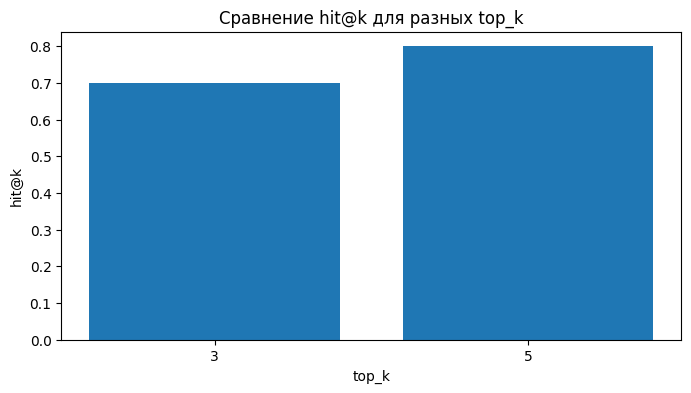

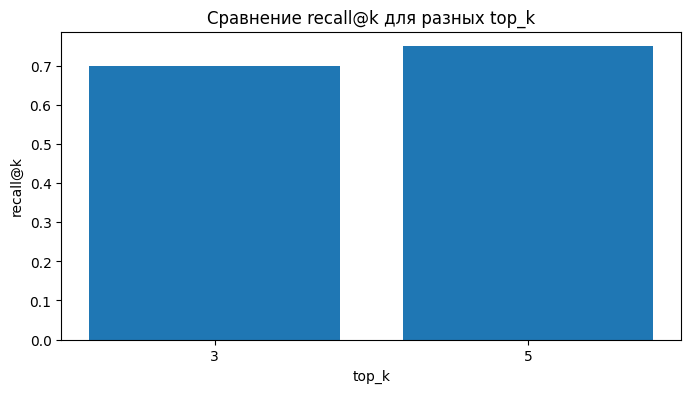

Выбран top_k по умолчанию: 5


In [14]:
experiment_rows = []
for candidate_top_k in [3, 5]:
    _, metrics = evaluate_retrieval(retriever, control_df, top_k=candidate_top_k)
    experiment_rows.append(metrics)

experiment_df = pd.DataFrame(experiment_rows)
display(experiment_df)

plt.figure(figsize=(8, 4))
plt.bar(experiment_df["top_k"].astype(str), experiment_df["hit@k"])
plt.title("Сравнение hit@k для разных top_k")
plt.xlabel("top_k")
plt.ylabel("hit@k")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(experiment_df["top_k"].astype(str), experiment_df["recall@k"])
plt.title("Сравнение recall@k для разных top_k")
plt.xlabel("top_k")
plt.ylabel("recall@k")
plt.show()

best_top_k = int(experiment_df.sort_values(["recall@k", "hit@k"], ascending=False).iloc[0]["top_k"])
print(f"Выбран top_k по умолчанию: {best_top_k}")

## 7. Обновление базы знаний и переиндексация

In [15]:
kb_updated_df = pd.concat([kb_df, pd.DataFrame(update_documents)], ignore_index=True)
chunks_updated_df = build_chunks(kb_updated_df, chunk_size=chunk_size, overlap=overlap)
retriever_updated = TfidfFaissRetriever(max_features=5000, ngram_range=(1, 2), svd_components=128).fit(chunks_updated_df)

print(f"Документов до обновления: {len(kb_df)}")
print(f"Документов после обновления: {len(kb_updated_df)}")
print(f"Чанков после обновления: {len(chunks_updated_df)}")
print(f"Updated TF-IDF matrix shape: {retriever_updated.tfidf_shape}")
print(f"Updated chunk embeddings shape: {retriever_updated.chunk_embeddings.shape}")

update_queries = [
    "Можно ли заморозить обучение на несколько недель?",
    "В какие часы проходят открытые консультации?",
    "Разрешены ли групповые итоговые проекты?",
    "Что происходит с дедлайнами во время заморозки обучения?"
]

comparison_rows = []
for query in update_queries:
    before = retriever.search(query, top_k=5)["source"].tolist()
    after = retriever_updated.search(query, top_k=5)["source"].tolist()
    before_unique = list(dict.fromkeys(before))
    after_unique = list(dict.fromkeys(after))

    comparison_rows.append({
        "query": query,
        "before_retrieved_sources": ", ".join(before_unique),
        "after_retrieved_sources": ", ".join(after_unique),
        "changed": before_unique != after_unique
    })

before_after_df = pd.DataFrame(comparison_rows)
display(before_after_df)

before_after_df.to_csv(ARTIFACTS_DIR / "retrieval_before_after_update.csv", index=False)
print(f"Файл сохранён: {ARTIFACTS_DIR / 'retrieval_before_after_update.csv'}")

Документов до обновления: 12
Документов после обновления: 15
Чанков после обновления: 50
Updated TF-IDF matrix shape: (50, 2377)
Updated chunk embeddings shape: (50, 50)


,query,before_retrieved_sources,after_retrieved_sources,changed
0,Можно ли заморозить обучение на несколько недель?,"technical_requirements, exam_rules, admission_...","technical_requirements, freeze_policy, exam_ru...",True
1,В какие часы проходят открытые консультации?,"learning_format, mentorship_support, final_pro...","office_hours, learning_format, mentorship_support",True
2,Разрешены ли групповые итоговые проекты?,"technical_requirements, community_rules, certi...","technical_requirements, community_rules, certi...",True
3,Что происходит с дедлайнами во время заморозки...,"exam_rules, admission_rules, community_rules","freeze_policy, exam_rules, admission_rules",True


Файл сохранён: homeworks\HW14\artifacts\retrieval_before_after_update.csv


In [16]:
for query in update_queries:
    print("=" * 100)
    print("QUERY:", query)
    print("До обновления:")
    display(retriever.search(query, top_k=5)[["source", "chunk_id", "score", "chunk_text"]])

    print("После обновления:")
    display(retriever_updated.search(query, top_k=5)[["source", "chunk_id", "score", "chunk_text"]])

QUERY: Можно ли заморозить обучение на несколько недель?
До обновления:


,source,chunk_id,score,chunk_text
0,technical_requirements,2,0.803459,или защиты проекта — работающая камера. Если к...
1,exam_rules,0,0.303731,На некоторых программах курс завершается итого...
2,admission_rules,0,0.266570,Онлайн-школа DataBridge Academy принимает студ...
3,admission_rules,1,0.214090,студент получает письмо с доступом к личному к...
4,learning_format,0,0.206286,Обучение в DataBridge Academy проходит в смеша...


После обновления:


,source,chunk_id,score,chunk_text
0,technical_requirements,2,0.788176,или защиты проекта — работающая камера. Если к...
1,freeze_policy,0,0.312608,"Если студент понимает, что временно не сможет ..."
2,exam_rules,0,0.281888,На некоторых программах курс завершается итого...
3,admission_rules,0,0.237149,Онлайн-школа DataBridge Academy принимает студ...
4,admission_rules,1,0.201770,студент получает письмо с доступом к личному к...


QUERY: В какие часы проходят открытые консультации?
До обновления:


...

,source,chunk_id,score,chunk_text
0,technical_requirements,2,6.547694e-01,или защиты проекта — работающая камера. Если к...
1,community_rules,0,5.990614e-01,Общий чат и форум курса предназначены для вопр...
2,community_rules,1,5.680454e-01,"тем как задать вопрос, школа рекомендует прове..."
3,technical_requirements,0,2.480462e-08,Для комфортной работы на курсе нужен ноутбук и...
4,certificates,1,2.188995e-08,Конкретный список обязательных работ указан в ...


QUERY: Что происходит с дедлайнами во время заморозки обучения?
До обновления:


,source,chunk_id,score,chunk_text
0,exam_rules,1,0.522924,"проверить камеру, микрофон и стабильность инте..."
1,exam_rules,0,0.508827,На некоторых программах курс завершается итого...
2,admission_rules,2,0.504746,возможен только по правилам заморозки обучения...
3,admission_rules,1,0.478427,студент получает письмо с доступом к личному к...
4,community_rules,1,0.246823,"тем как задать вопрос, школа рекомендует прове..."


После обновления:


,source,chunk_id,score,chunk_text
0,freeze_policy,0,0.575803,"Если студент понимает, что временно не сможет ..."
1,exam_rules,1,0.440940,"проверить камеру, микрофон и стабильность инте..."
2,exam_rules,0,0.429372,На некоторых программах курс завершается итого...
3,admission_rules,2,0.386790,возможен только по правилам заморозки обучения...
4,freeze_policy,1,0.384027,зафиксировать статус в системе. На время замор...


## 8. Mini-RAG

In [17]:
STOPWORDS = {
    "и", "в", "во", "на", "по", "с", "со", "к", "ко", "о", "об", "от", "до", "за", "из", "у",
    "а", "но", "или", "ли", "что", "как", "какие", "какой", "какая", "когда", "где", "можно",
    "нужно", "для", "это", "этот", "эта", "эти", "бы", "быть", "не", "же", "то", "если"
}

def tokenize(text: str):
    tokens = re.findall(r"[а-яА-Яa-zA-Z0-9]+", text.lower())
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

def sentence_split(text: str):
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]

def build_context(retriever_obj, question: str, top_k: int = 5):
    results = retriever_obj.search(question, top_k=top_k)
    context_chunks = []
    for _, row in results.iterrows():
        context_chunks.append({
            "source": row["source"],
            "text": row["chunk_text"],
            "score": row["score"]
        })
    return context_chunks

def extractive_answer(question: str, context_chunks, max_sentences: int = 3):
    q_tokens = set(tokenize(question))
    sentence_candidates = []

    for item in context_chunks:
        for sent in sentence_split(item["text"]):
            sent_tokens = set(tokenize(sent))
            overlap = len(q_tokens & sent_tokens)
            if overlap > 0:
                sentence_candidates.append((overlap, item["score"], item["source"], sent))

    sentence_candidates.sort(key=lambda x: (x[0], x[1]), reverse=True)

    selected = []
    seen = set()
    for overlap, score, source, sent in sentence_candidates:
        key = sent.lower()
        if key not in seen:
            selected.append((source, sent))
            seen.add(key)
        if len(selected) >= max_sentences:
            break

    if not selected:
        sources = list(dict.fromkeys([c["source"] for c in context_chunks[:3]]))
        return (
            "В найденном контексте нет достаточно точного фрагмента для уверенного ответа. Нужна дополнительная проверка базы знаний или более точная формулировка вопроса.",
            sources
        )

    answer = " ".join([sent for _, sent in selected])
    sources = list(dict.fromkeys([source for source, _ in selected]))
    return answer, sources

def mini_rag_answer(question: str, retriever_obj, top_k: int = 5):
    context_chunks = build_context(retriever_obj, question, top_k=top_k)
    answer, sources = extractive_answer(question, context_chunks, max_sentences=3)
    return {
        "question": question,
        "answer": answer,
        "retrieved_sources": sources
    }

rag_questions = [
    "Как получить сертификат по окончании курса?",
    "Что делать, если я пропустил жесткий дедлайн по домашнему заданию?",
    "Можно ли сделать паузу в обучении на месяц?",
    "Когда проходят консультационные часы?",
    "Разрешён ли групповой итоговый проект?"
]

rag_examples = [mini_rag_answer(q, retriever_updated, top_k=best_top_k) for q in rag_questions]
rag_examples_df = pd.DataFrame(rag_examples)
rag_examples_df["retrieved_sources"] = rag_examples_df["retrieved_sources"].apply(lambda x: ", ".join(x))
display(rag_examples_df)

rag_examples_df.to_csv(ARTIFACTS_DIR / "rag_examples.csv", index=False)
print(f"Файл сохранён: {ARTIFACTS_DIR / 'rag_examples.csv'}")

,question,answer,retrieved_sources
0,Как получить сертификат по окончании курса?,"курса, это может привести к академическому отс...","deadlines_resubmissions, certificates"
1,"Что делать, если я пропустил жесткий дедлайн п...",Жёсткий дедлайн закрывает модуль. У каждого до...,deadlines_resubmissions
2,Можно ли сделать паузу в обучении на месяц?,Поэтому для сохранения академического статуса ...,"freeze_policy, community_rules, final_project"
3,Когда проходят консультационные часы?,По базовому регламенту консультационные часы п...,office_hours
4,Разрешён ли групповой итоговый проект?,Базовая схема такая: 50 процентов итоговой оце...,"grading_policy, group_project_policy"


Файл сохранён: homeworks\HW14\artifacts\rag_examples.csv


In [18]:
for _, row in rag_examples_df.iterrows():
    print("=" * 100)
    print("QUESTION:", row["question"])
    print("ANSWER:", row["answer"])
    print("SOURCES:", row["retrieved_sources"])

QUESTION: Как получить сертификат по окончании курса?
ANSWER: курса, это может привести к академическому отставанию и невозможности получить сертификат в текущем потоке. Сертификат об окончании программы выдаётся студентам, которые выполнили обязательный минимум требований. Если выполнена только часть программы, школа может выдать справку о прохождении отдельных модулей, но это не заменяет сертификат о завершении курса.
SOURCES: deadlines_resubmissions, certificates
QUESTION: Что делать, если я пропустил жесткий дедлайн по домашнему заданию?
ANSWER: Жёсткий дедлайн закрывает модуль. У каждого домашнего задания есть мягкий и жёсткий дедлайн.
SOURCES: deadlines_resubmissions
QUESTION: Можно ли сделать паузу в обучении на месяц?
ANSWER: Поэтому для сохранения академического статуса важно заранее оформить паузу официально. Хороший вопрос содержит контекст: что студент хотел сделать, что именно пошло не так, какой код или текст ошибки получился. Он должен показывать, что студент умеет приме

## Краткий анализ ошибок и пограничных случаев

Mini-RAG показал нормальное качество на простых фактических вопросах, но на части запросов возникали ошибки retrieval и смешение контекста. Ниже приведены наиболее показательные случаи.

### 1. Вопрос о возврате денег после старта обучения
Для запроса **«Можно ли вернуть деньги после старта обучения?»** retrieval не нашёл правильный источник `payments_refunds` в top-k. Вместо этого в выдаче оказались `technical_requirements` и `admission_rules`. Это пример ошибки именно на этапе retrieval: нужный документ есть в базе, но не был поднят достаточно высоко.

### 2. Вопрос о технических требованиях
Для запроса **«Какие технические требования к ноутбуку и программам?»** retrieval также не попал в ожидаемый источник `technical_requirements`. В top-k первым оказался `admission_rules`. Этот случай показывает, что при близкой тематике документов система может путать общие организационные правила и технические требования.

### 3. Ответ mini-RAG про сертификат
На вопрос **«Как получить сертификат по окончании курса?»** mini-RAG дал частично полезный ответ, но начал его с фрагмента из `deadlines_resubmissions`, который относится скорее к дедлайнам, чем к сертификату. После этого в ответ был использован уже релевантный документ `certificates`. Здесь проблема связана с тем, что retrieval вернул вместе и полезный, и лишний контекст.

### 4. Ответ mini-RAG про паузу в обучении
На вопрос **«Можно ли сделать паузу в обучении на месяц?»** после обновления базы знаний retrieval уже находил `freeze_policy`, но итоговый ответ всё равно содержал лишние элементы из других источников. Это пограничный случай, когда обновление базы улучшило поиск, но простая схема сборки ответа всё ещё допускает попадание нерелевантного текста.

### Вывод
Основные ошибки связаны с двумя причинами: retrieval не всегда точно ранжирует документы для близких по теме запросов, а простой способ сборки ответа может включать лишние фрагменты из top-k контекста. Поэтому качество mini-RAG напрямую зависит от того, насколько чистый и релевантный набор источников был найден на этапе retrieval.